In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

## Preprocessing

In [3]:
pd.set_option("display.max_columns", 200)

df_og = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_df_5.csv", encoding='utf-8-sig')

df_og.columns = df_og.columns.str.strip()

df_og = df_og[df_og['전체점포'] != 0].reset_index(drop=True) # 전체점포 X 제거 -> 빈 시장


df = df_og.copy()

In [4]:
def safe_div(numer, denom):
    numer = numer.astype(float)
    denom = denom.astype(float)
    out = np.where((denom > 0) & np.isfinite(numer) & np.isfinite(denom), numer / denom, np.nan)
    return out

# 파생변수 생성
df["빈점포율"] = safe_div(df["빈점포"], df["전체점포"])
df['운영점포수'] = df["전체점포"] - df["빈점포"]
df["점포_대_상인_비율"] = safe_div(df['운영점포수'], df["총시장상인"])
df.loc[(df["빈점포율"] < 0) | (df["빈점포율"] > 1), "빈점포율"] = np.nan
df["delivery_grocery"] = ((df["delivery"] == 1) | (df["grocery"] == 1)).astype(int)



print(df[["빈점포율", "점포_대_상인_비율", "운영점포수", "delivery_grocery"]].describe(percentiles=[.01,.05,.5,.95,.99]))
print("NaN 비율:\n", df[["빈점포율", "점포_대_상인_비율"]].isna().mean())

             빈점포율  점포_대_상인_비율        운영점포수  delivery_grocery
count  833.000000  833.000000   833.000000        833.000000
mean     0.106260    0.677478   134.963986          0.090036
std      0.164211    0.233253   268.952243          0.286405
min      0.000000    0.046610     1.000000          0.000000
1%       0.000000    0.209949     8.000000          0.000000
5%       0.000000    0.301701    17.600000          0.000000
50%      0.039474    0.675676    77.000000          0.000000
95%      0.469937    1.000000   450.800000          1.000000
99%      0.738137    1.324483  1061.000000          1.000000
max      0.900000    1.962617  4688.000000          1.000000
NaN 비율:
 빈점포율          0.0
점포_대_상인_비율    0.0
dtype: float64


In [5]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [item for item in cat_cols if item not in ['시장명', '지번주소', '도로명주소', '시도', '시군구', 'market_item_type']]


le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df["편의시설수"] = df[cat_cols].sum(axis=1)

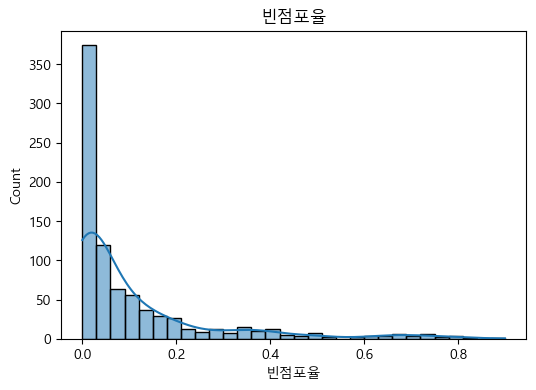

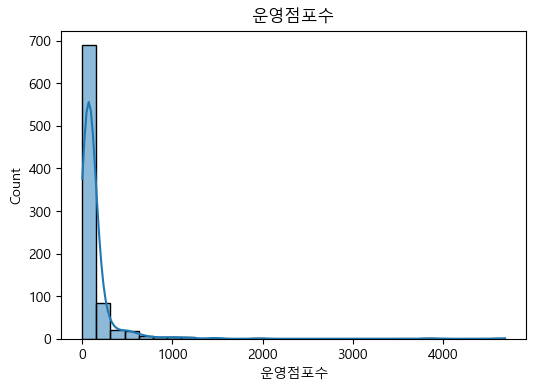

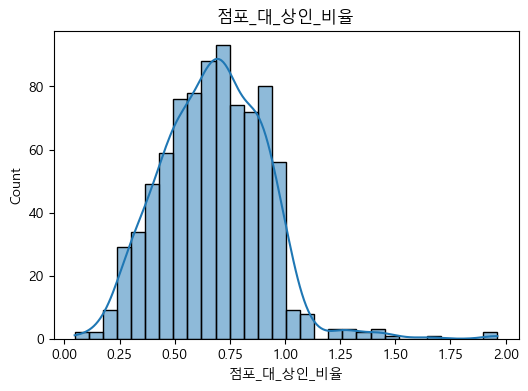

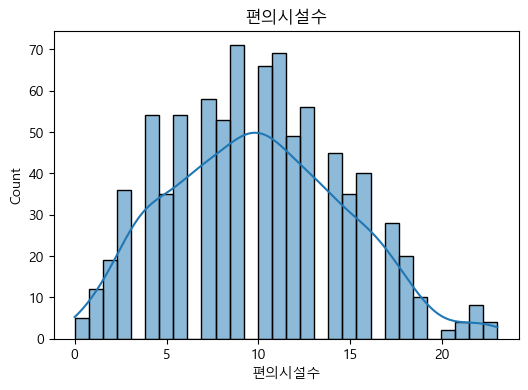

In [6]:
# 파생변수 생성
# 빈점포율: 전체 점포 중 빈 점포 비율
# 점포_대_상인_비율: 빈점포를 뺀 점포 대비 상인의 비율로 점포의 실질적 운영 효율을 의미
# 편의시설수: 시장 내 비치된 편의시설의 수
key_cols = ["빈점포율", '운영점포수', "점포_대_상인_비율", "편의시설수"]

for c in key_cols:
    if c in df.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(df[c], bins=30, kde=True)
        plt.title(c)
        plt.show()

In [7]:
non_lists = ['아케이드 보유 여부',
 '엘리베이터_에스컬레이터_보유여부',
 '고객지원센터 보유 여부',
 '스프링쿨러 보유 여부',
 '화재감지기 보유여부',
 '유아놀이방_보유여부',
 '종합콜센터_보유여부',
 '고객휴게실_보유여부',
 '수유센터_보유여부',
 '물품보관함_보유여부',
 '자전거보관함_보유여부',
 '체육시설_보유여부',
 '간이 도서관_보유여부',
 '쇼핑카트_보유여부',
 '외국인 안내센터_보유여부',
 '고객동선통로_보유여부',
 '방송센터_보유여부',
 '문화교실_보유여부',
 '공동물류창고_보유여부',
 '시장전용 고객주차장_보유여부',
 '교육장_보유여부',
 '회의실_보유여부',
 '자동심장충격기_보유여부', '위도', '경도']

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols.remove('행정기관코드')
num_cols = [item for item in num_cols if item not in non_lists]

print("Numeric:", len(num_cols))

Numeric: 38


### numeric 변수 분포 확인

In [8]:
def scan_numeric_distribution(df, cols, n=15):
    for c in cols[:n]:
        fig, ax = plt.subplots(1, 2, figsize=(10,3))
        sns.histplot(df[c], bins=30, ax=ax[0])
        sns.boxplot(x=df[c], ax=ax[1])
        fig.suptitle(c)
        plt.show()

In [9]:
num_cols[22:]

['pop_f',
 'pop_adole',
 'pop_young',
 'pop_middle',
 'pop_senior',
 'parking',
 'bus',
 'mart',
 'tour',
 'conv',
 'subway',
 '빈점포율',
 '운영점포수',
 '점포_대_상인_비율',
 'delivery_grocery',
 '편의시설수']

In [10]:
store_cols = num_cols[:9] + ['편의시설수'] + ['운영점포수'] + ['점포_대_상인_비율']
type_cols = num_cols[9:20] + ['delivery_grocery']
pop_cols = num_cols[20:27]
access_cols = num_cols[27:33]

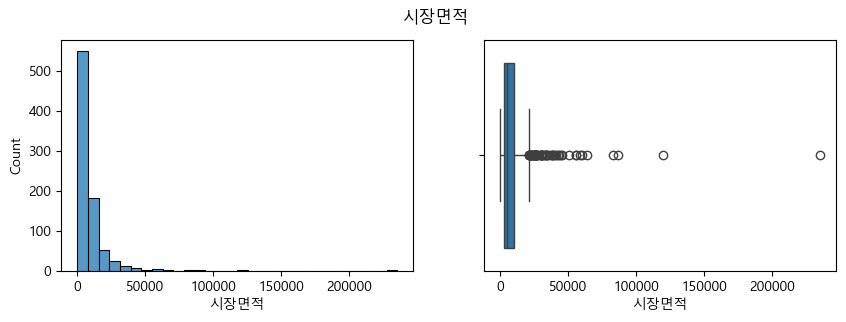

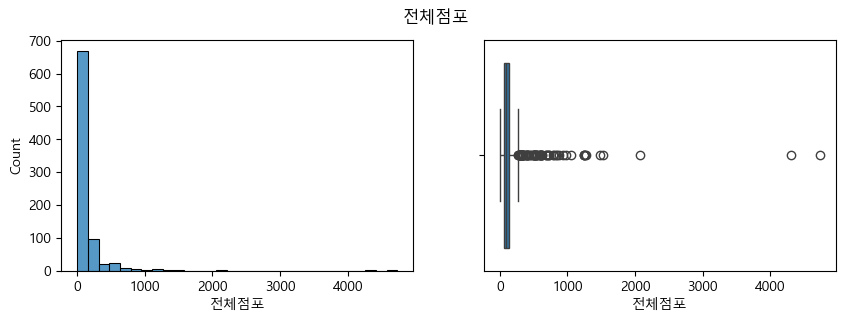

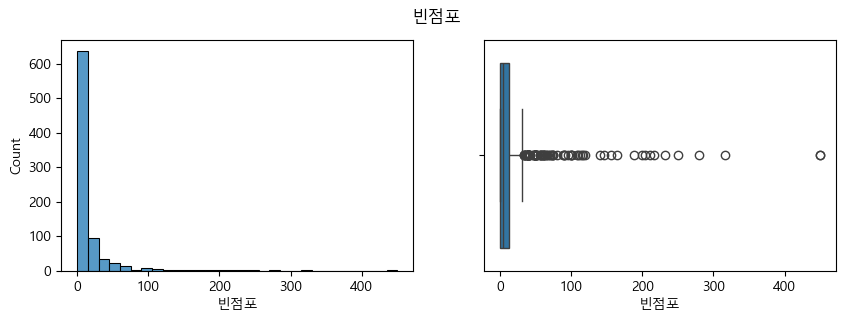

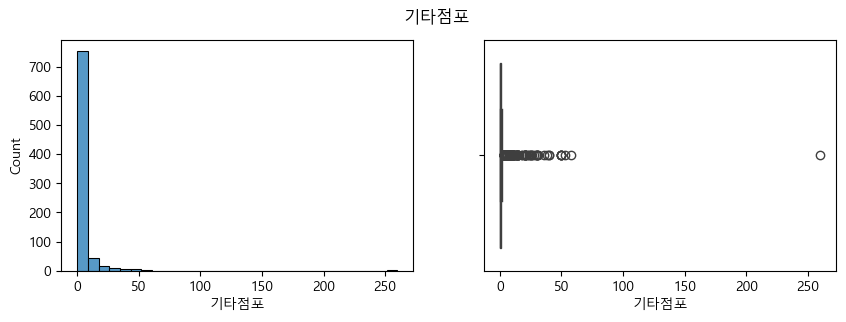

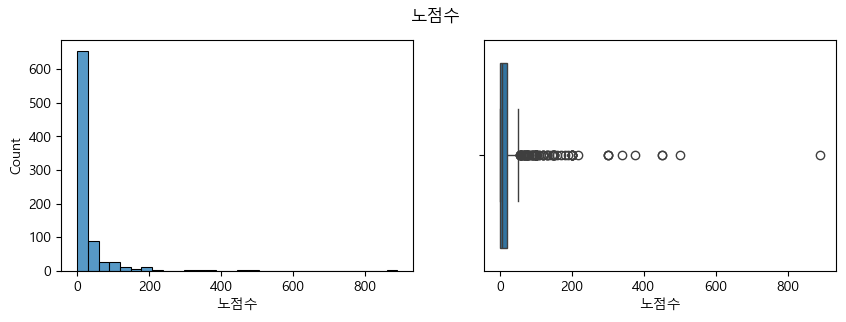

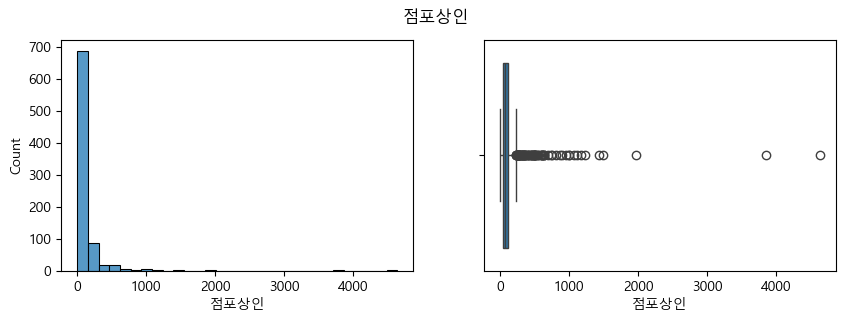

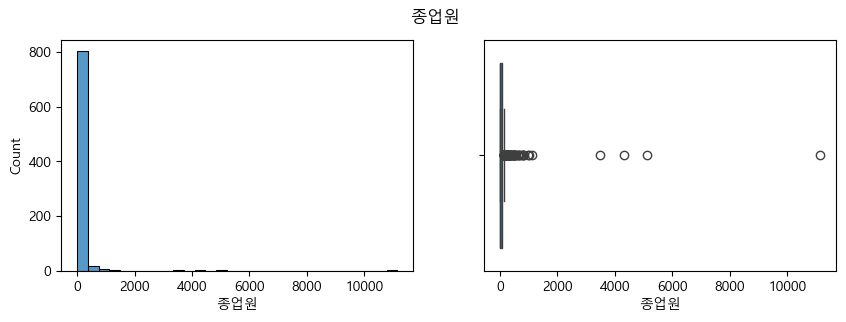

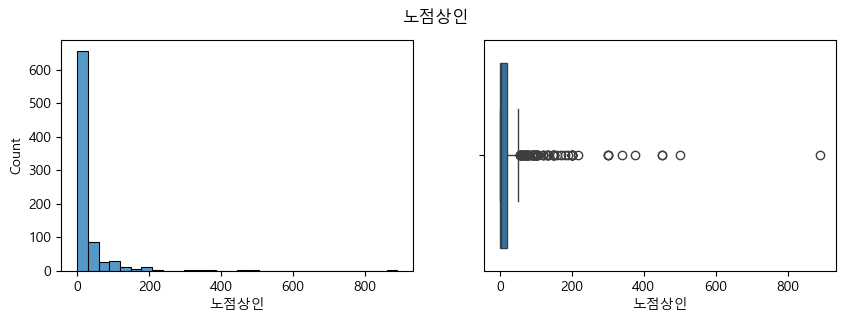

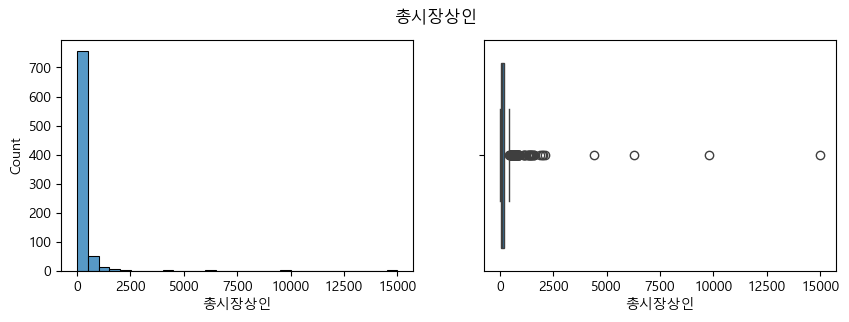

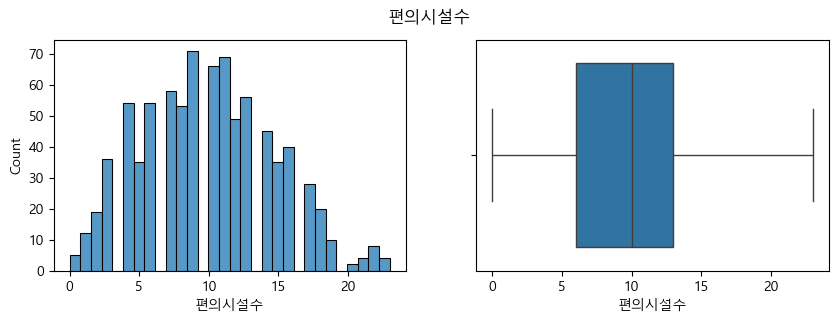

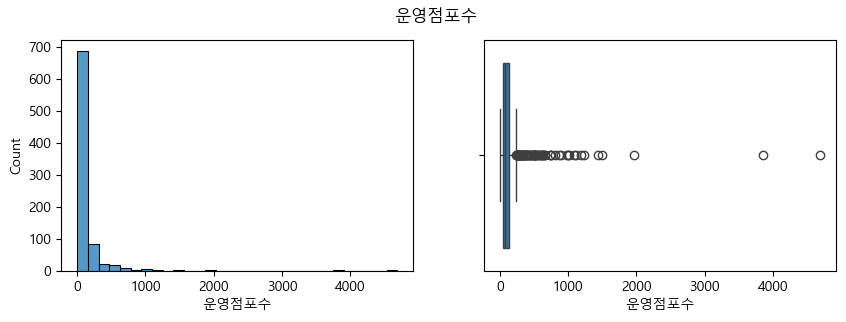

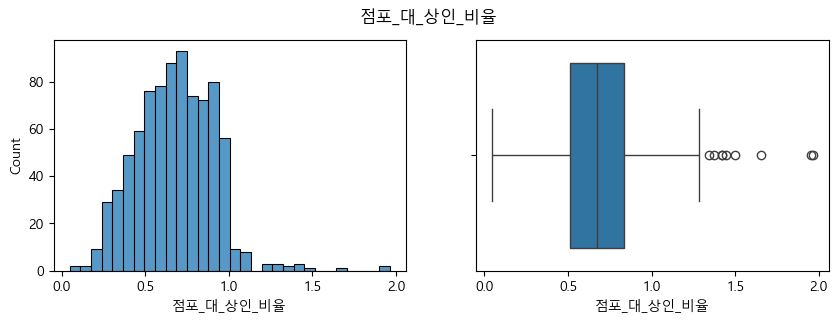

In [33]:
scan_numeric_distribution(df, store_cols)

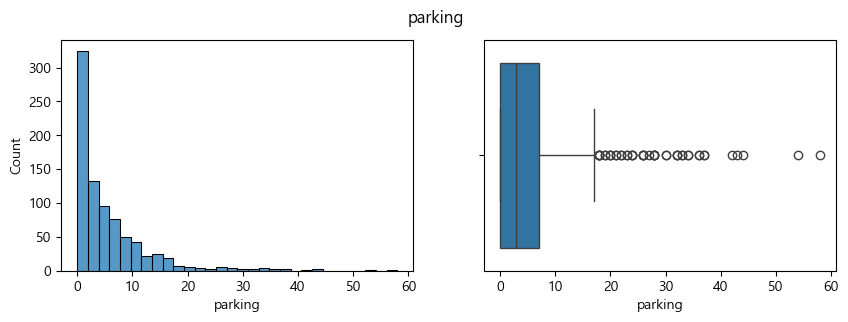

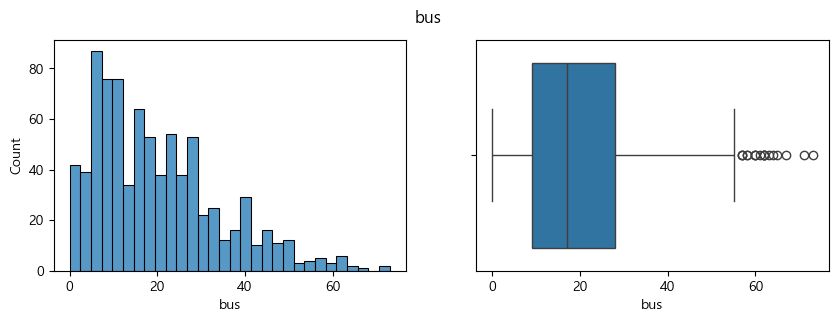

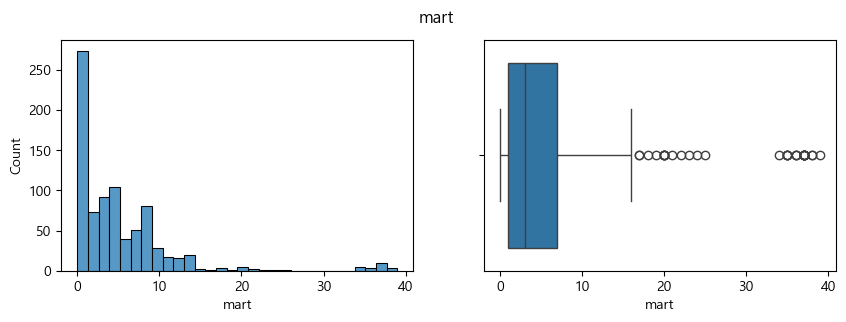

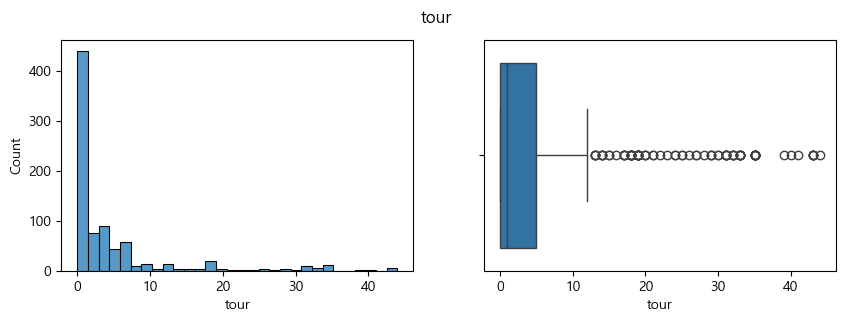

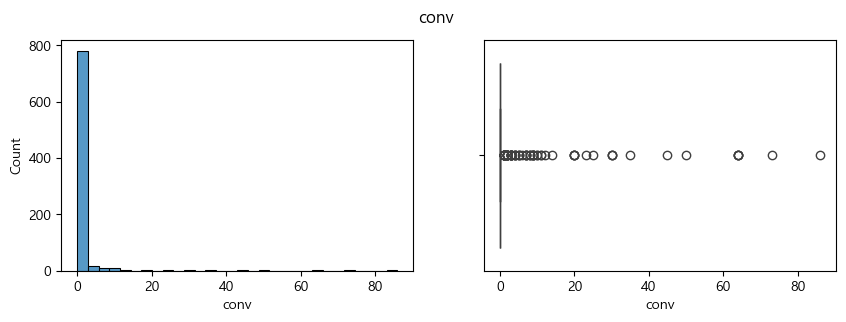

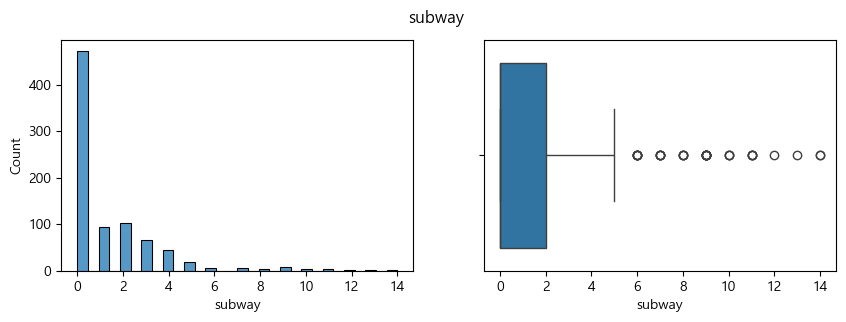

In [41]:
scan_numeric_distribution(df, access_cols)

### 산점도

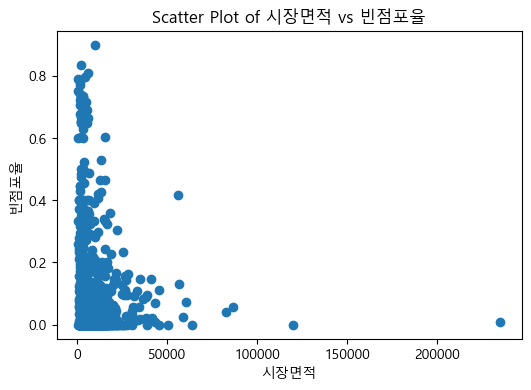

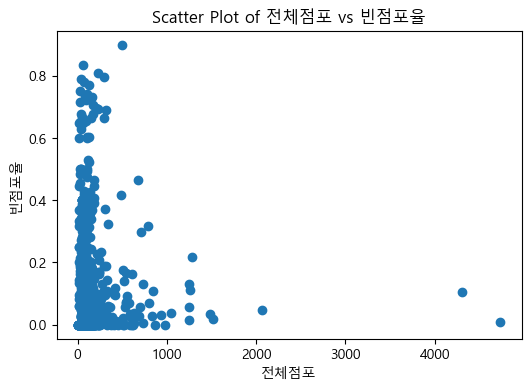

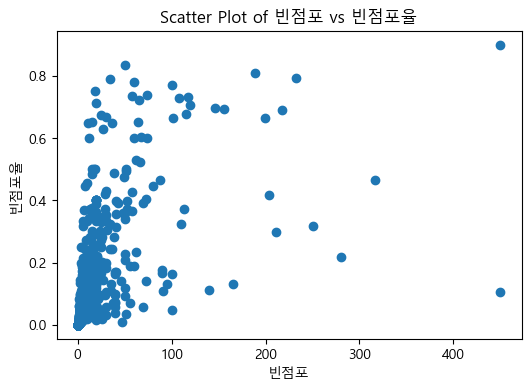

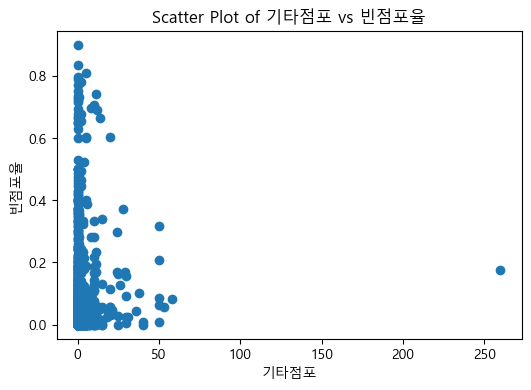

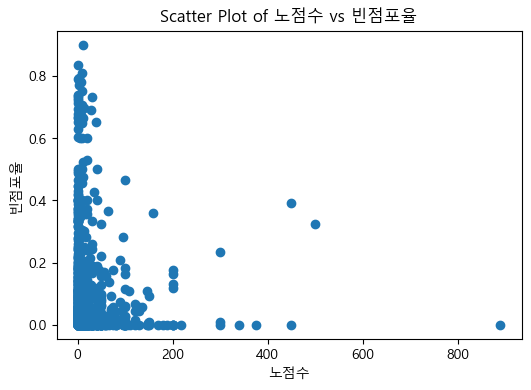

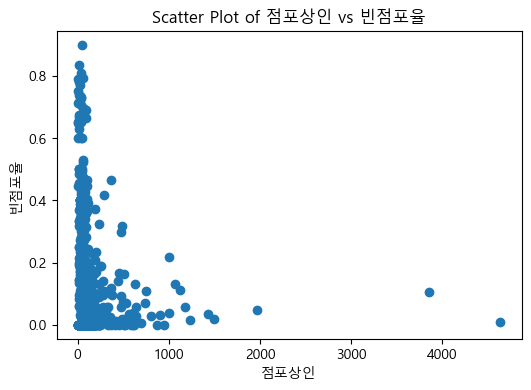

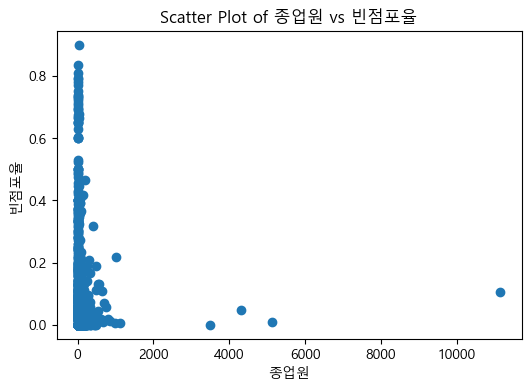

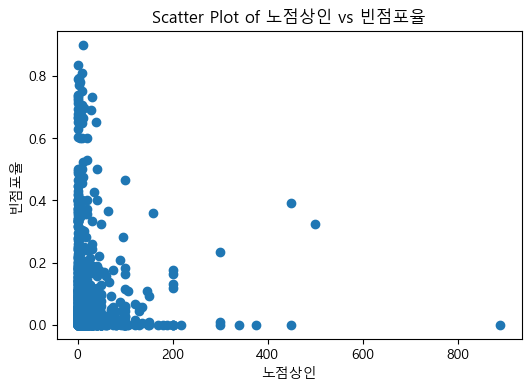

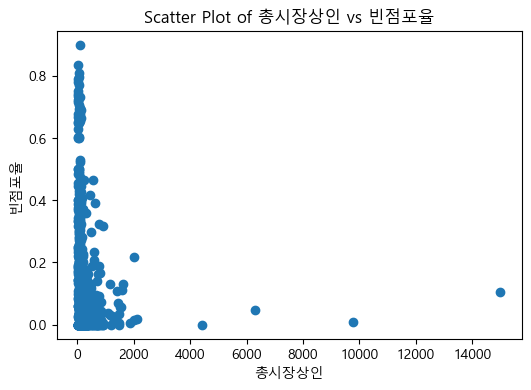

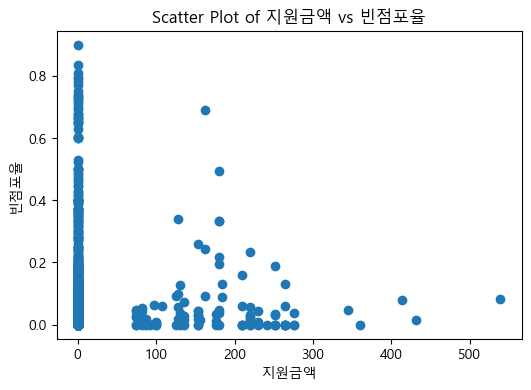

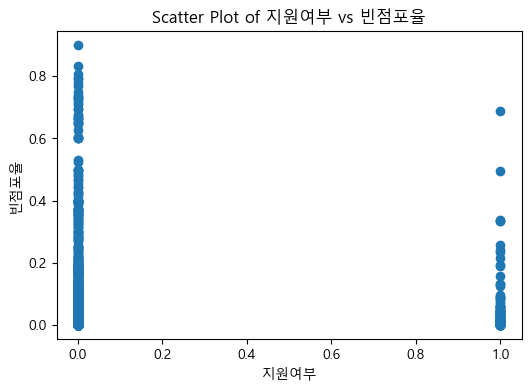

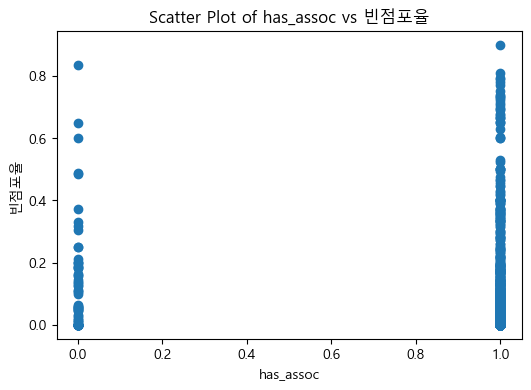

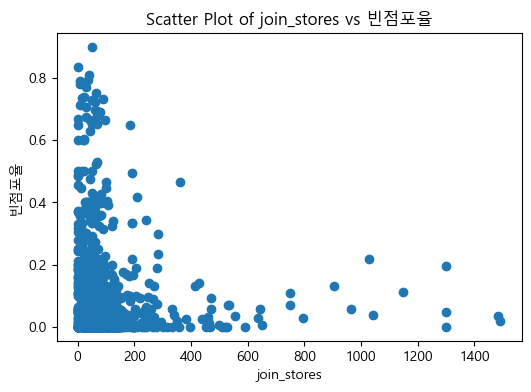

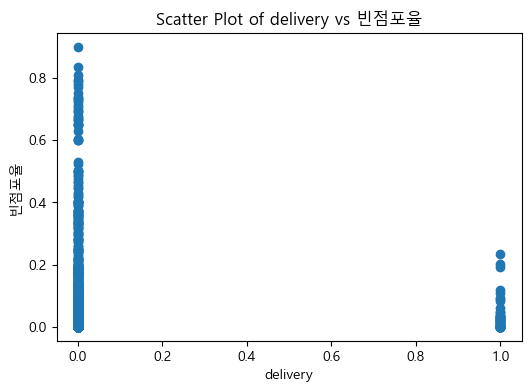

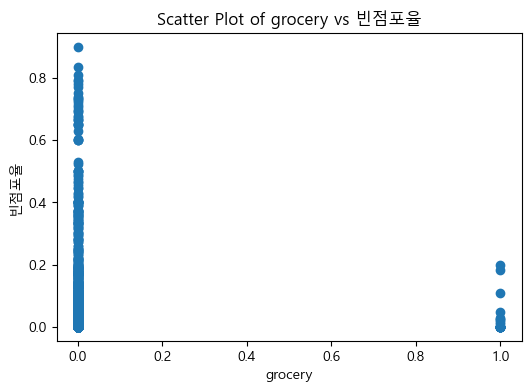

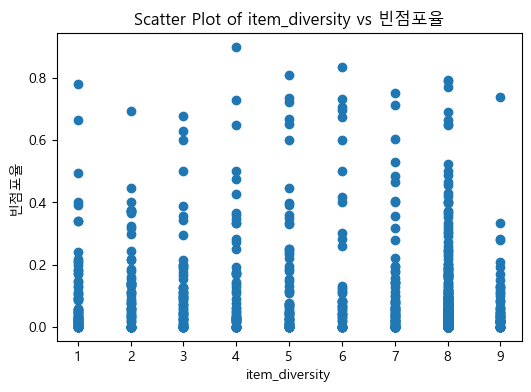

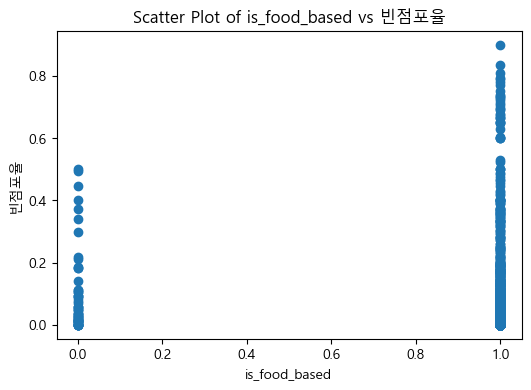

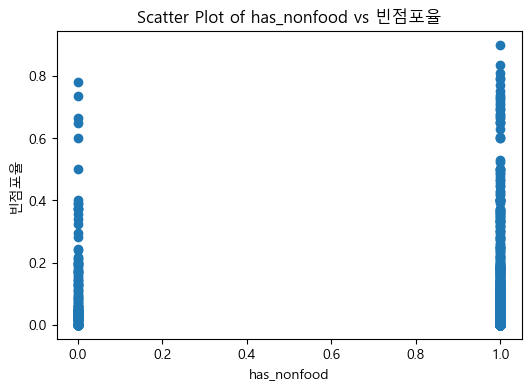

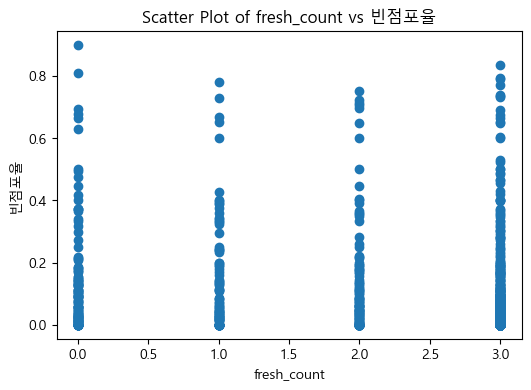

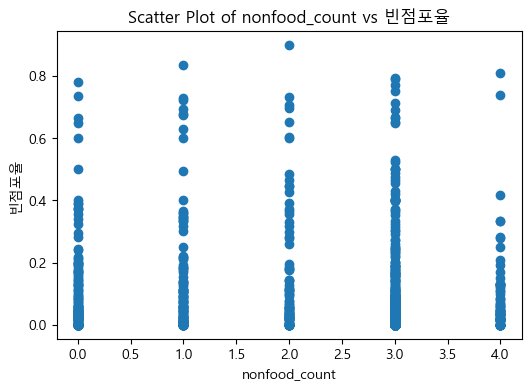

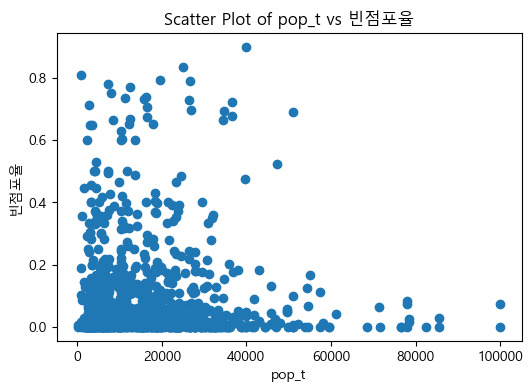

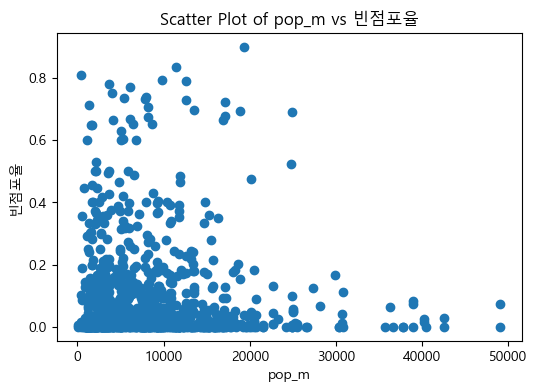

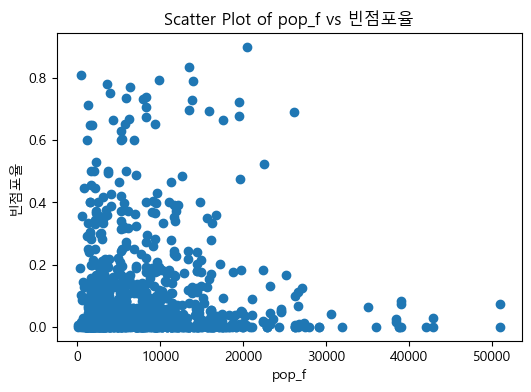

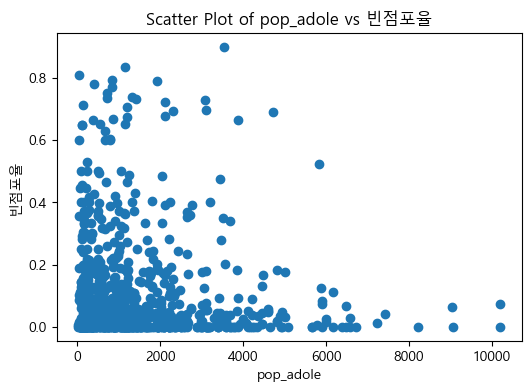

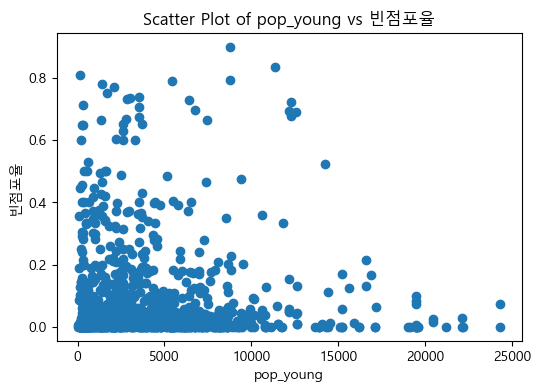

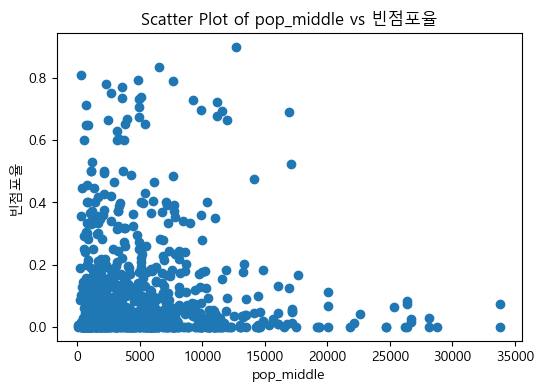

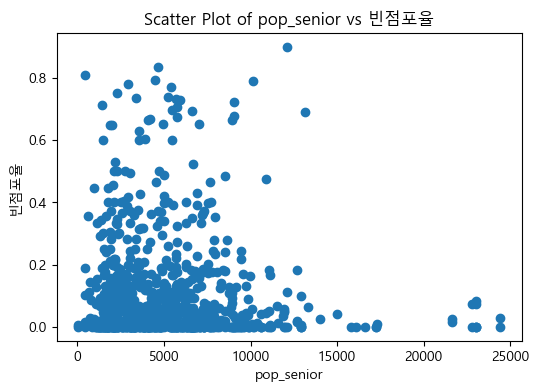

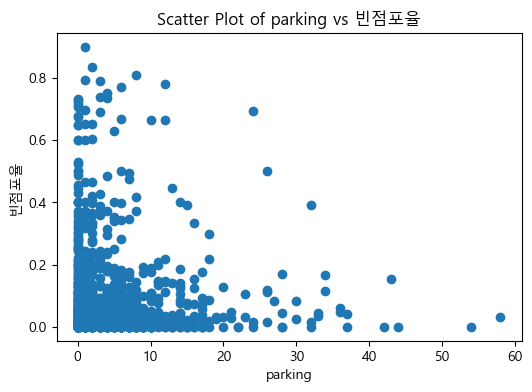

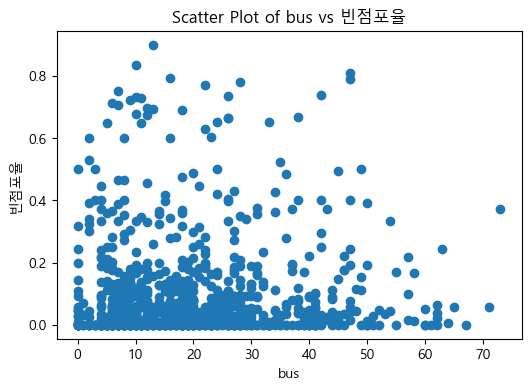

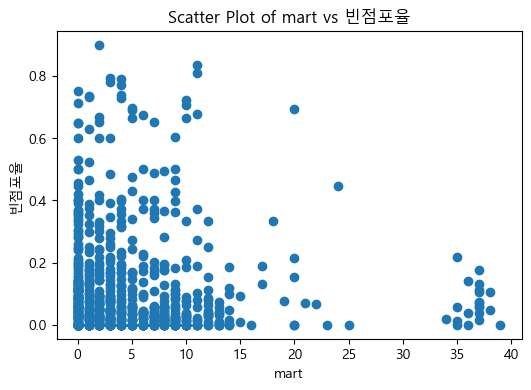

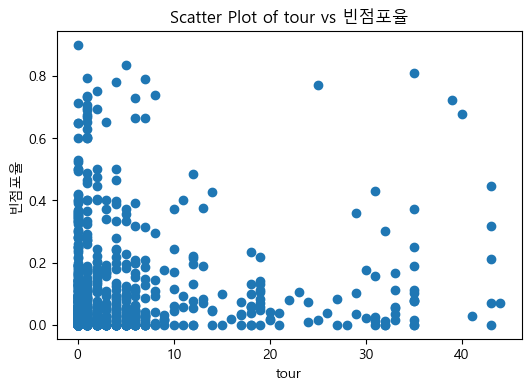

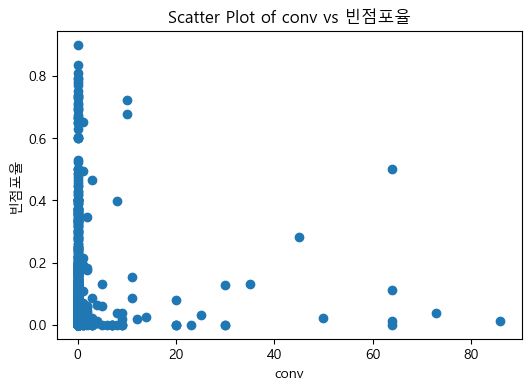

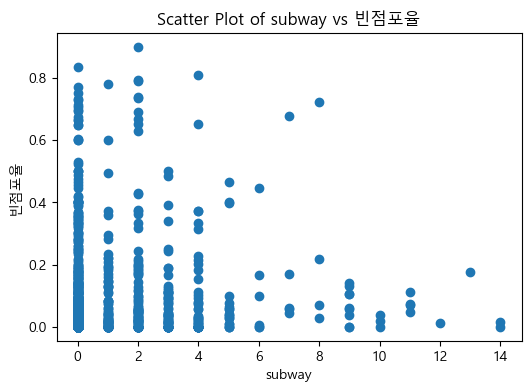

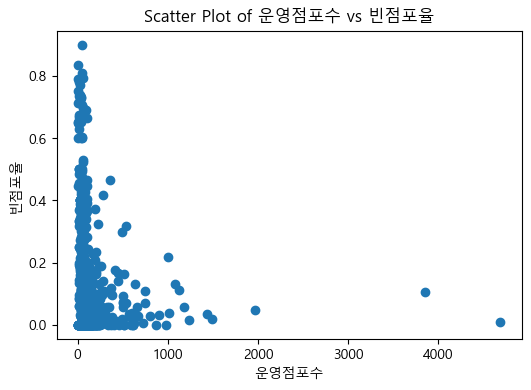

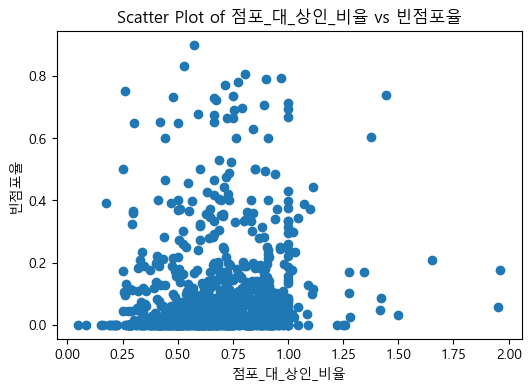

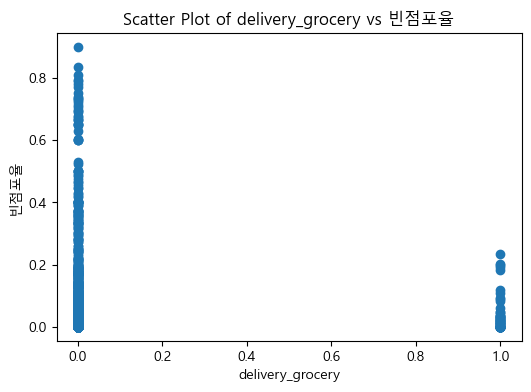

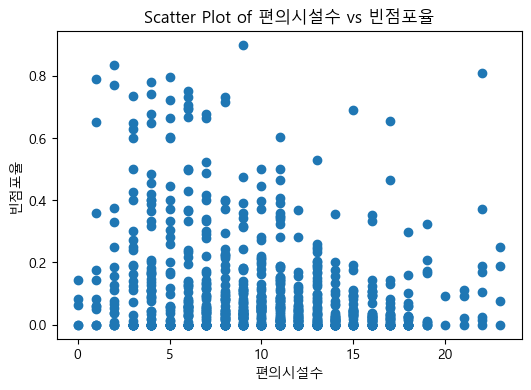

In [42]:
# 빈점포율 vs 나머지 변수들에 대한 산점도를 반복적으로 그리기
for column in num_cols:
    if column != '빈점포율':
        plt.figure(figsize=(6, 4))  # 각 산점도를 적당한 크기로 설정
        plt.scatter(df[column], df['빈점포율'])
        plt.xlabel(column)
        plt.ylabel('빈점포율')
        plt.title(f'Scatter Plot of {column} vs {'빈점포율'}')
        plt.show()

## 상관계수 계산

### 히트맵

In [11]:
corr = df[num_cols].corr()

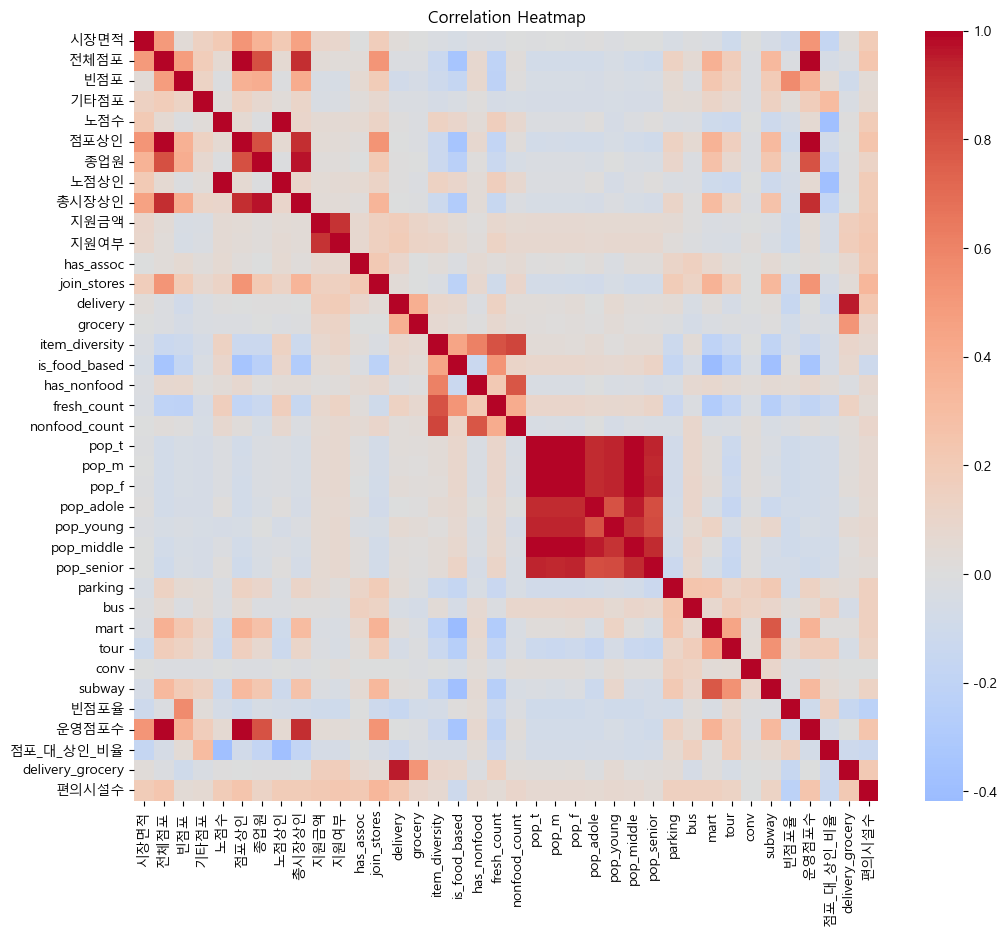

In [12]:
corr = df[num_cols].corr()
# 전체
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

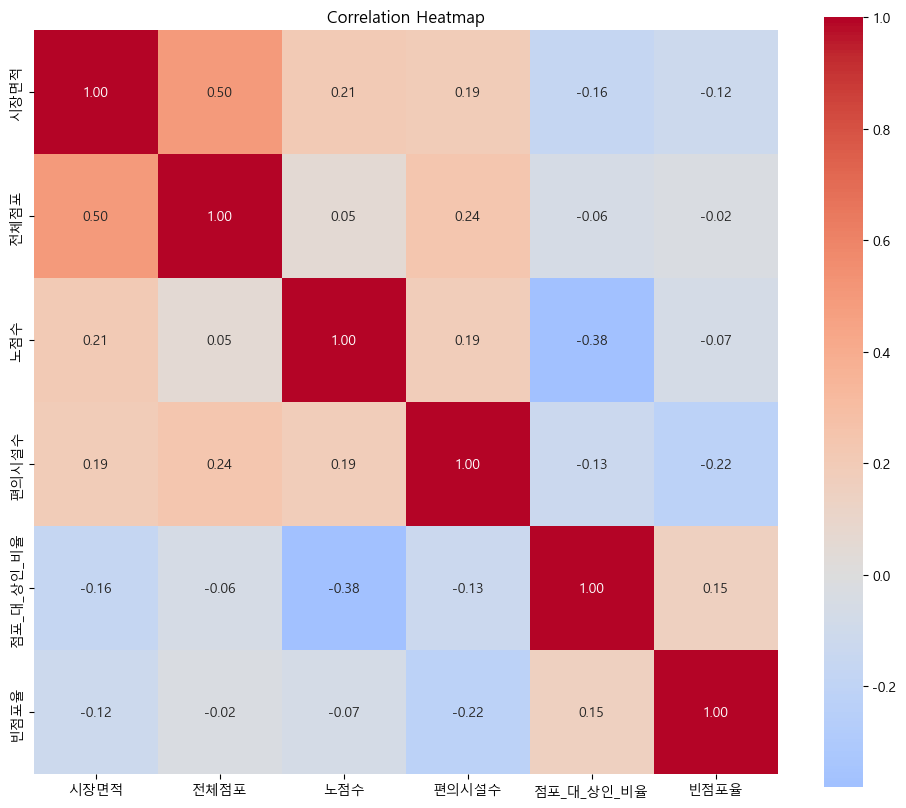

In [16]:
#corr_1 = df[store_cols  + ['빈점포율']].corr()
corr_1 = df[['시장면적', '전체점포', '노점수', '편의시설수', '점포_대_상인_비율']  + ['빈점포율']].corr()


plt.figure(figsize=(12,10))
sns.heatmap(corr_1, cmap="coolwarm", center=0,
        annot=True,
        fmt=".2f",
        square=True)
plt.title("Correlation Heatmap")
plt.show()


In [67]:
upper_1 = corr_1.abs().where(
    np.triu(np.ones(corr_1.abs().shape), k=1).astype(bool)
)

high_corr_pairs_1 = (
    upper_1
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "var_1",
        "level_1": "var_2",
        0: "abs_corr"
    })
    .query("abs_corr >= 0.8")
    .sort_values("abs_corr", ascending=False)
)

high_corr_pairs_1


,var_1,var_2,abs_corr


* 운영점포수, 빈점포, 노점상인, 기타점포, 점포상인, 종업원 제외

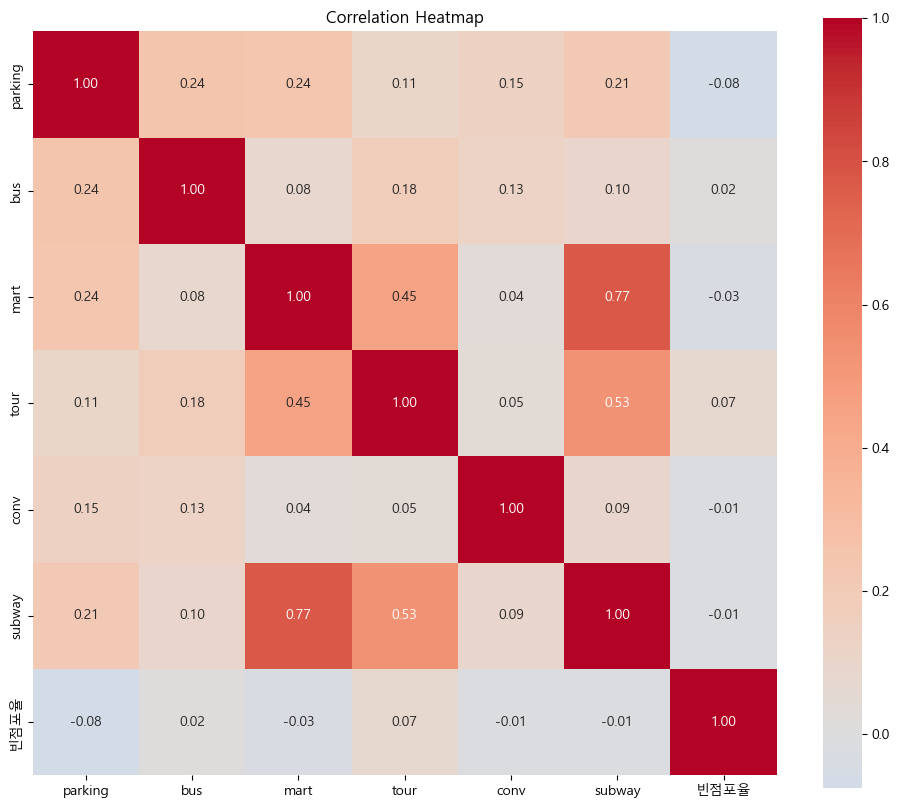

In [68]:
# 
corr_2 = df[access_cols + ['빈점포율']].corr()


plt.figure(figsize=(12,10))
sns.heatmap(corr_2, cmap="coolwarm", center=0,
        annot=True,
        fmt=".2f",
        square=True)
plt.title("Correlation Heatmap")
plt.show()


In [69]:
upper_2 = corr_2.abs().where(
    np.triu(np.ones(corr_2.abs().shape), k=1).astype(bool)
)

high_corr_pairs_2 = (
    upper_2
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "var_1",
        "level_1": "var_2",
        0: "abs_corr"
    })
    .query("abs_corr >= 0.8")
    .sort_values("abs_corr", ascending=False)
)

high_corr_pairs_2


,var_1,var_2,abs_corr


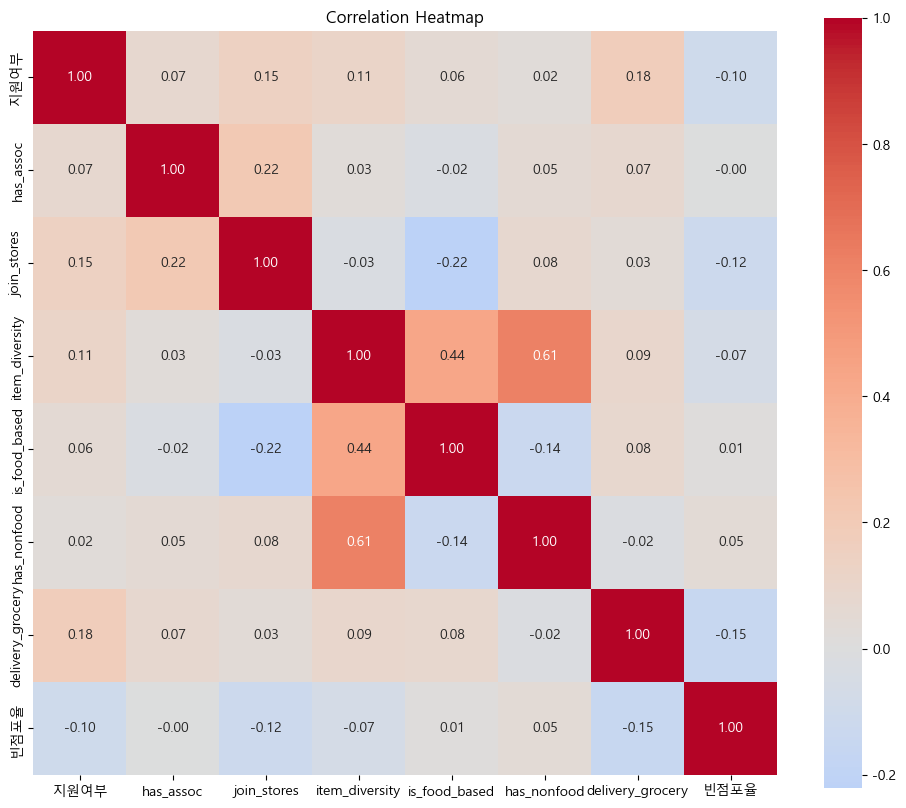

In [17]:
#
#corr_3 = df[type_cols  + ['빈점포율']].corr()
corr_3 = df[['지원여부', 'has_assoc', 'join_stores', 'item_diversity', 'is_food_based', 'has_nonfood', 'delivery_grocery']  + ['빈점포율']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_3, cmap="coolwarm", center=0,
        annot=True,
        fmt=".2f",
        square=True)
plt.title("Correlation Heatmap")
plt.show()


In [79]:
upper_3 = corr_3.abs().where(
    np.triu(np.ones(corr_3.abs().shape), k=1).astype(bool)
)

high_corr_pairs_3 = (
    upper_3
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "var_1",
        "level_1": "var_2",
        0: "abs_corr"
    })
    .query("abs_corr >= 0.8")
    .sort_values("abs_corr", ascending=False)
)

high_corr_pairs_3


,var_1,var_2,abs_corr


* 지원금액, delivery, grocery, nonfood_count, fresh_count 제거

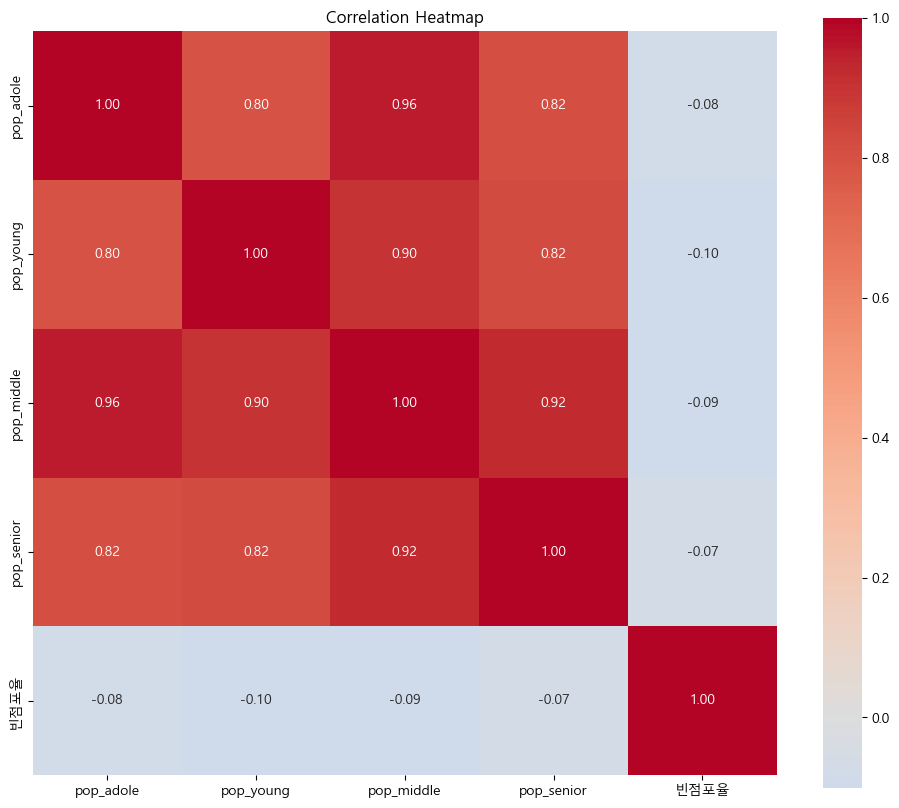

In [83]:
# type
#corr_4 = df[pop_cols  + ['빈점포율']].corr()
corr_4 = df[['pop_adole', 'pop_young', 'pop_middle', 'pop_senior']  + ['빈점포율']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_4, cmap="coolwarm", center=0,
        annot=True,
        fmt=".2f",
        square=True)
plt.title("Correlation Heatmap")
plt.show()


In [84]:
upper_4 = corr_4.abs().where(
    np.triu(np.ones(corr_4.abs().shape), k=1).astype(bool)
)

high_corr_pairs_4 = (
    upper_4
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "var_1",
        "level_1": "var_2",
        0: "abs_corr"
    })
    .query("abs_corr >= 0.8")
    .sort_values("abs_corr", ascending=False)
)

high_corr_pairs_4


,var_1,var_2,abs_corr
1,pop_adole,pop_middle,0.955280
7,pop_middle,pop_senior,0.919618
4,pop_young,pop_middle,0.902148
5,pop_young,pop_senior,0.823718
2,pop_adole,pop_senior,0.816919


* 연령대 별로만 남겨놓음

### 범주화

In [94]:
def binarize_gt0(s):
    s = pd.to_numeric(s, errors="coerce").fillna(0)
    return (s > 0).astype(int)

In [ ]:
#df["subway"] = binarize_gt0(df["subway"])
#df["tour"]   = binarize_gt0(df["tour"])
#df["conv"]   = binarize_gt0(df["conv"])

In [86]:
df["delivery_grocery"] = (
    df[["delivery", "grocery"]]
    .fillna(0)
    .sum(axis=1)
    .gt(0)
    .astype(int)
)

## final_cols

In [120]:
final_cols = ['시장면적', '전체점포', '노점수', "총시장상인", '편의시설수', '점포_대_상인_비율'] + access_cols + ['pop_adole', 'pop_young', 'pop_middle', 'pop_senior'] + ['지원여부', 'has_assoc', 'join_stores', 'item_diversity', 'is_food_based', 'has_nonfood', 'market_item_type', 'delivery_grocery'] + ['빈점포율']


In [121]:
df_merged = pd.concat(
    [
        df_og[['행정기관코드', '시장명', '시도', '시군구', '위도', '경도']],
        df[final_cols]
    ],
    axis=1
)

## 최종 변수

In [123]:
df_merged.head(3)

,행정기관코드,시장명,시도,시군구,위도,경도,시장면적,전체점포,노점수,총시장상인,편의시설수,점포_대_상인_비율,parking,bus,mart,tour,conv,subway,pop_adole,pop_young,pop_middle,pop_senior,지원여부,has_assoc,join_stores,item_diversity,is_food_based,has_nonfood,market_item_type,delivery_grocery,빈점포율
0,3114051000,(주)신정시장,울산광역시,남구,35.542374,129.310261,1668,90,4,110,10,0.781818,4,25,4,0,0,0,1035,4575,5459,6306,1.0,1.0,78.0,7.0,1.0,1.0,복합형(생활+비식품),0,0.044444
1,3114062500,수암상가시장,울산광역시,남구,35.526896,129.320722,6628,83,49,191,10,0.434555,0,22,4,0,0,0,3595,8231,10959,6326,0.0,1.0,88.0,8.0,1.0,1.0,복합형(생활+비식품),0,0.000000
2,3114062500,수암종합시장,울산광역시,남구,35.527650,129.320771,2205,52,43,103,7,0.485437,0,26,4,0,0,0,3595,8231,10959,6326,0.0,1.0,43.0,5.0,1.0,1.0,복합형(생활+비식품),0,0.038462


## 저장

In [125]:
df_merged.to_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_df_merged.csv", encoding = 'utf-8-sig', index_label = False)